In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cProfile
import pstats

# Configure matplotlib
plt.style.use('fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

In [8]:
from src import get_alphabet
L = 10
max_order = 2
alphabet = get_alphabet('dna')
alpha = len(alphabet)
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data=1.0/alpha)

In [9]:
# Get features
from src import get_pairwise_model_features
features = get_pairwise_model_features(L=L, alphabet=alphabet)

# Create random values from normal distribution
values = np.random.normal(size=len(features))

# Create series with features as index and random values
feature_series = pd.Series(data=values, index=features)
feature_series


((), )         -0.137554
((0,), A)       0.060676
((0,), C)      -0.384102
((0,), D)      -1.710290
((0,), E)      -0.204328
                  ...   
((3, 4), YS)   -1.828027
((3, 4), YT)    0.474152
((3, 4), YV)   -1.048270
((3, 4), YW)    0.442555
((3, 4), YY)   -0.420956
Length: 4101, dtype: float64

In [12]:
from src.get_hg_projection_matrix import get_hg_projection_matrix
P = get_hg_projection_matrix(features=features, L=L, alphabet=alphabet, bg_df=bg_df, out_type='sparse')

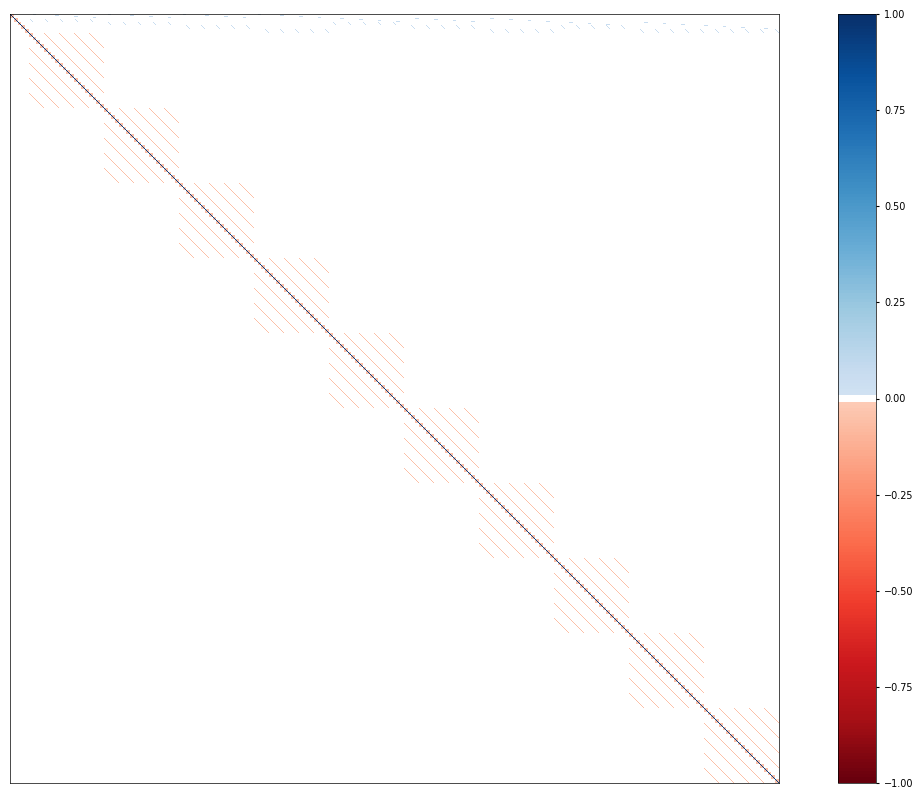

In [11]:
from src.matrix_visualizer import visualize_matrix
visualize_matrix(P, show_grid=False)